In [30]:
import pandas as pd
import numpy as np
import re
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, precision_recall_curve
import matplotlib.pyplot as plt
import joblib
pd.set_option('display.max_columns', None)

In [1]:
train_df = pd.read_csv("../../data/processed/combinedWithOdds.csv")

eval_df = pd.read_csv("../../data/evaluation/secondIterration/202425.csv")

print("Training shape:", train_df.shape)
print("Evaluation shape:", eval_df.shape)
print("Training columns:", train_df.columns.tolist())
print("Evaluation columns:", eval_df.columns.tolist())

Training shape: (12931, 127)
Evaluation shape: (380, 120)
Training columns: ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'VCH', 'VCD', 'VCA', 'BWH', 'BWD', 'BWA', 'GBH', 'GBD', 'GBA', 'IWH', 'IWD', 'IWA', 'LBH', 'LBD', 'LBA', 'SBH', 'SBD', 'SBA', 'SJH', 'SJD', 'SJA', 'WHH', 'WHD', 'WHA', 'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA', 'B365>2.5', 'B365<2.5', 'GB>2.5', 'GB<2.5', 'SOH', 'SOD', 'SOA', 'Time', 'B365AHH', 'B365AHA', 'PSH', 'PSD', 'PSA', 'P>2.5', 'P<2.5', 'PAHH', 'PAHA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'AHh', 'BSH', 'BSD', 'BSA', 'Attendance', 'HHW', 'AHW', 'HO', 'AO', 'SYH', 'SYD', 'SYA', '1XBH',

In [2]:
train_cols = set(train_df.columns)
eval_cols = set(eval_df.columns)

missing_in_eval = train_cols - eval_cols
extra_in_eval = eval_cols - train_cols

print("Columns in train but missing in eval:")
print(sorted(list(missing_in_eval)))
print("\nColumns in eval but missing in train:")
print(sorted(list(extra_in_eval)))

Columns in train but missing in eval:
['AHW', 'AO', 'Attendance', 'B365AH', 'BSA', 'BSD', 'BSH', 'Bb1X2', 'BbAH', 'BbAHh', 'BbAv<2.5', 'BbAv>2.5', 'BbAvA', 'BbAvAHA', 'BbAvAHH', 'BbAvD', 'BbAvH', 'BbMx<2.5', 'BbMx>2.5', 'BbMxA', 'BbMxAHA', 'BbMxAHH', 'BbMxD', 'BbMxH', 'BbOU', 'GB<2.5', 'GB>2.5', 'GBA', 'GBAH', 'GBAHA', 'GBAHH', 'GBD', 'GBH', 'HHW', 'HO', 'IWA', 'IWD', 'IWH', 'LBA', 'LBAH', 'LBAHA', 'LBAHH', 'LBD', 'LBH', 'SBA', 'SBD', 'SBH', 'SJA', 'SJD', 'SJH', 'SOA', 'SOD', 'SOH', 'SYA', 'SYD', 'SYH', 'VCA', 'VCD', 'VCH']

Columns in eval but missing in train:
['1XBCA', '1XBCD', '1XBCH', 'AHCh', 'AvgC<2.5', 'AvgC>2.5', 'AvgCA', 'AvgCAHA', 'AvgCAHH', 'AvgCD', 'AvgCH', 'B365C<2.5', 'B365C>2.5', 'B365CA', 'B365CAHA', 'B365CAHH', 'B365CD', 'B365CH', 'BFCA', 'BFCD', 'BFCH', 'BFE<2.5', 'BFE>2.5', 'BFEAHA', 'BFEAHH', 'BFEC<2.5', 'BFEC>2.5', 'BFECA', 'BFECAHA', 'BFECAHH', 'BFECD', 'BFECH', 'BWCA', 'BWCD', 'BWCH', 'MaxC<2.5', 'MaxC>2.5', 'MaxCA', 'MaxCAHA', 'MaxCAHH', 'MaxCD', 'MaxCH', 'PC<2.

In [3]:
columns_to_keep = [
    'Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
    'HTHG', 'HTAG', 'HTR', 'Attendance', 'Referee', 'HS', 'AS', 'HST', 'AST',
    'HHW', 'AHW', 'HC', 'AC', 'HF', 'AF', 'HFKC', 'AFKC', 'HO', 'AO', 'HY', 'AY',
    'HR', 'AR', '1XBH', '1XBD', '1XBA', 'B365H', 'B365D', 'B365A', 'B365>2.5', 'B365<2.5', 'B365AHH', 'B365AHA', 'B365AH',
    'BFH', 'BFD', 'BFA', 'BFEH', 'BFED', 'BFEA', 'BFDH', 'BFDD', 'BFDA',
    'BMGMH', 'BMGMD', 'BMGMA', 'BVH', 'BVD', 'BVA', 'VCH', 'VCD', 'VCA',
    'BSH', 'BSD', 'BSA', 'BWH', 'BWD', 'BWA', 'CLH', 'CLD', 'CLA',
    'GBH', 'GBD', 'GBA', 'GB>2.5', 'GB<2.5', 'GBAHH', 'GBAHA', 'GBAH',
    'IWH', 'IWD', 'IWA', 'LBH', 'LBD', 'LBA', 'LBAHH', 'LBAHA', 'LBAH',
    'PSH', 'PH', 'PSD', 'PD', 'PSA', 'PA', 'P>2.5', 'P<2.5', 'PAHH', 'PAHA',
    'SOH', 'SOD', 'SOA', 'SBH', 'SBD', 'SBA', 'SJH', 'SJD', 'SJA',
    'SYH', 'SYD', 'SYA', 'WHH', 'WHD', 'WHA',
    'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA',
    'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5',
    'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA',
    'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA',
    'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5',
    'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'AHh'
]

In [4]:
for df in [train_df, eval_df]:
    for col in columns_to_keep:
        if col not in df.columns:
            df[col] = 0 
    df = df[columns_to_keep]

In [5]:
train_df = train_df[columns_to_keep]
eval_df = eval_df[columns_to_keep]

In [6]:
def clean_and_engineer_features(
    df,
    columns_to_keep,
    all_teams=None, 
    fit_teams=False,
    n_matches=5,
    drop_cols=['Time', 'Attendance', 'HHW', 'AHW', 'HO', 'AO', 'Div'],
):
    for col in columns_to_keep:
        if col not in df.columns:
            df[col] = np.nan

    df = df[columns_to_keep].copy()
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

    def date_format_type(date_str):
        if not isinstance(date_str, str):
            return "not_a_string"
        patterns = {
            "%d/%m/%y": r"^\d{2}/\d{2}/\d{2}$",
            "%d/%m/%Y": r"^\d{2}/\d{2}/\d{4}$",
            "%Y-%m-%d": r"^\d{4}-\d{2}-\d{2}$",
            "%m-%d-%Y": r"^\d{2}-\d{2}-\d{4}$",
            "%Y/%m/%d": r"^\d{4}/\d{2}/\d{2}$",
        }
        for fmt, pat in patterns.items():
            if re.match(pat, date_str):
                return fmt
        return "unknown"
    df['DateFormat'] = df['Date'].apply(date_format_type)
    def parse_dates(row):
        date_str = row['Date']
        if isinstance(date_str, str):
            try:
                return pd.to_datetime(date_str, format='%d/%m/%y')
            except ValueError:
                try:
                    return pd.to_datetime(date_str, format='%d/%m/%Y')
                except ValueError:
                    return pd.NaT
        else:
            return pd.NaT
    df['Date'] = df.apply(parse_dates, axis=1)
    df = df.drop(columns=['DateFormat'], errors='ignore')
    df = df[df['Date'] >= pd.Timestamp('2000-08-18')]
    df = df.reset_index(drop=True)

    def get_season(date):
        if pd.isnull(date):
            return np.nan
        year = date.year
        month = date.month
        if month >= 8:
            return f"{year}-{str(year+1)[-2:]}"
        else:
            return f"{year-1}-{str(year)[-2:]}"
    df['Season'] = df['Date'].apply(get_season)
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['DayOfWeek'] = df['Date'].dt.dayofweek

    odds_cols = [
        'B365H', 'B365D', 'B365A', 'B365>2.5', 'B365<2.5', 'B365AHH', 'B365AHA', 'B365AH',
        'IWH', 'IWD', 'IWA', 'WHH', 'WHD', 'WHA', 'PSH', 'PSD', 'PSA', 'PH', 'PD', 'PA',
        'P>2.5', 'P<2.5', 'PAHH', 'PAHA', 'LBH', 'LBD', 'LBA', 'LBAHH', 'LBAHA', 'LBAH',
        'GBH', 'GBD', 'GBA', 'GB>2.5', 'GB<2.5', 'GBAHH', 'GBAHA', 'GBAH', 'BVH', 'BVD', 'BVA',
        'VCH', 'VCD', 'VCA', '1XBH', '1XBD', '1XBA', 'BWH', 'BWD', 'BWA', 'SOH', 'SOD', 'SOA',
        'SBH', 'SBD', 'SBA', 'CLH', 'CLD', 'CLA', 'BMGMH', 'BMGMD', 'BMGMA', 'BFDH', 'BFDD', 'BFDA',
        'BFH', 'BFD', 'BFA', 'BFEH', 'BFED', 'BFEA', 'SYH', 'SYD', 'SYA', 'SJH', 'SJD', 'SJA',
        'BSH', 'BSD', 'BSA', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU',
        'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH',
        'BbMxAHA', 'BbAvAHA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'Max>2.5', 'Max<2.5',
        'Avg>2.5', 'Avg<2.5', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'AHh'
    ]
    score_cols = [
        'FTHG', 'FTAG', 'HTHG', 'HTAG', 'HS', 'AS', 'HST', 'AST',
        'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR'
    ]
    for col in odds_cols + score_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.drop_duplicates()

    essential_odds = ['B365H', 'B365D', 'B365A', 'WHH', 'WHD', 'WHA', 'IWH', 'IWD', 'IWA']
    core_odds = odds_cols
    essentials = [col for col in essential_odds if col in df.columns]
    df = df.dropna(subset=essentials).reset_index(drop=True)
    for col in core_odds:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mean())

    newcols = {}
    newcols['TotalGoals'] = df['FTHG'] + df['FTAG']
    newcols['GoalsOver2_5'] = (newcols['TotalGoals'] > 2.5).astype(int)
    newcols['BTTS'] = ((df['FTHG'] > 0) & (df['FTAG'] > 0)).astype(int)
    newcols['Home_2plus'] = (df['FTHG'] >= 2).astype(int)
    newcols['Away_2plus'] = (df['FTAG'] >= 2).astype(int)
    df = pd.concat([df, pd.DataFrame(newcols, index=df.index)], axis=1)
    df = df.copy() 

    df = df.sort_values('Date')
    df['HomeTeam_mean_FTHG'] = (
        df.groupby('HomeTeam')['FTHG'].transform(lambda x: x.shift(1).expanding().mean())
    )
    df['AwayTeam_mean_FTAG'] = (
        df.groupby('AwayTeam')['FTAG'].transform(lambda x: x.shift(1).expanding().mean())
    )

    df['HomeTeam_str'] = df['HomeTeam']
    df['AwayTeam_str'] = df['AwayTeam']
    if fit_teams:
        unique_teams = sorted(set(df['HomeTeam_str']).union(set(df['AwayTeam_str'])))
    else:
        unique_teams = all_teams
    team_onehot = {}
    for team in unique_teams:
        team_onehot[f"HomeTeam_{team}"] = (df['HomeTeam_str'] == team).astype(int)
        team_onehot[f"AwayTeam_{team}"] = (df['AwayTeam_str'] == team).astype(int)
    df = pd.concat([df, pd.DataFrame(team_onehot, index=df.index)], axis=1)
    df = df.drop(columns=['HomeTeam', 'AwayTeam'], errors='ignore')
    df = df.rename(columns={'HomeTeam_str': 'HomeTeam', 'AwayTeam_str': 'AwayTeam'})
    df = df.copy()

    def add_recent_form_features(df, n_matches=5):
        base = df.copy()
        base = base.sort_values('Date')
        home_df = base[['Date', 'HomeTeam', 'FTHG', 'FTAG']].rename(
            columns={'HomeTeam': 'Team', 'FTHG': 'GoalsFor', 'FTAG': 'GoalsAgainst'})
        away_df = base[['Date', 'AwayTeam', 'FTAG', 'FTHG']].rename(
            columns={'AwayTeam': 'Team', 'FTAG': 'GoalsFor', 'FTHG': 'GoalsAgainst'})
        results = pd.concat([home_df, away_df], ignore_index=True)
        results = results.sort_values(['Team', 'Date'])
        def get_points(row):
            return 3 if row['GoalsFor'] > row['GoalsAgainst'] else (1 if row['GoalsFor'] == row['GoalsAgainst'] else 0)
        results['Points'] = results.apply(get_points, axis=1)
        results['RollingGF'] = results.groupby('Team')['GoalsFor'].transform(lambda x: x.shift(1).rolling(n_matches, min_periods=1).mean())
        results['RollingGA'] = results.groupby('Team')['GoalsAgainst'].transform(lambda x: x.shift(1).rolling(n_matches, min_periods=1).mean())
        results['RollingPoints'] = results.groupby('Team')['Points'].transform(lambda x: x.shift(1).rolling(n_matches, min_periods=1).sum())
        def get_form(row, team_col):
            team = row[team_col]
            date = row['Date']
            row_form = results[(results['Team'] == team) & (results['Date'] < date)].sort_values('Date').tail(1)
            if row_form.empty:
                return pd.Series([np.nan, np.nan, np.nan])
            return row_form[['RollingGF', 'RollingGA', 'RollingPoints']].values[0]
        base[['HomeRecentGF', 'HomeRecentGA', 'HomeRecentPts']] = base.apply(
            lambda row: get_form(row, 'HomeTeam'), axis=1, result_type='expand')
        base[['AwayRecentGF', 'AwayRecentGA', 'AwayRecentPts']] = base.apply(
            lambda row: get_form(row, 'AwayTeam'), axis=1, result_type='expand')
        return base
    df = add_recent_form_features(df, n_matches=n_matches)
    df = df.dropna(subset=['HomeRecentGF', 'AwayRecentGF'])

    df = df.sort_values('Date')
    h2h_home_wins = []
    team_stats = {}
    home_positions = []
    away_positions = []
    for idx, row in df.iterrows():
        home = row['HomeTeam']
        away = row['AwayTeam']
        match_date = row['Date']
        prev_matches = df[
            (((df['HomeTeam'] == home) & (df['AwayTeam'] == away)) |
             ((df['HomeTeam'] == away) & (df['AwayTeam'] == home)))
            & (df['Date'] < match_date)
        ].sort_values('Date', ascending=False).head(5)
        home_wins = ((prev_matches['HomeTeam'] == home) & (prev_matches['FTHG'] > prev_matches['FTAG'])).sum()
        h2h_home_wins.append(home_wins)
        league_table = []
        for team, stats in team_stats.items():
            league_table.append({
                'team': team,
                'points': stats['points'],
                'gd': stats['gd'],
                'scored': stats['scored']
            })
        table_df = pd.DataFrame(league_table)
        if not table_df.empty:
            table_df = table_df.sort_values(['points', 'gd', 'scored'], ascending=[False, False, False])
            table_df['position'] = range(1, len(table_df) + 1)
            home_pos = table_df[table_df['team'] == home]['position'].values[0] if home in table_df['team'].values else len(table_df) + 1
            away_pos = table_df[table_df['team'] == away]['position'].values[0] if away in table_df['team'].values else len(table_df) + 1
        else:
            home_pos = away_pos = 1
        home_positions.append(home_pos)
        away_positions.append(away_pos)
        home_goals = row['FTHG']
        away_goals = row['FTAG']
        for team in [home, away]:
            if team not in team_stats:
                team_stats[team] = {'points': 0, 'gd': 0, 'scored': 0}
        if home_goals > away_goals:
            team_stats[home]['points'] += 3
        elif home_goals < away_goals:
            team_stats[away]['points'] += 3
        else:
            team_stats[home]['points'] += 1
            team_stats[away]['points'] += 1
        team_stats[home]['gd'] += home_goals - away_goals
        team_stats[away]['gd'] += away_goals - home_goals
        team_stats[home]['scored'] += home_goals
        team_stats[away]['scored'] += away_goals
    h2h_leaguecols = pd.DataFrame({
        'h2h_home_wins_last5': h2h_home_wins,
        'home_league_position': home_positions,
        'away_league_position': away_positions,
        'position_diff': np.array(home_positions) - np.array(away_positions)
    }, index=df.index)
    df = pd.concat([df, h2h_leaguecols], axis=1)
    df = df.copy()

    N = 5
    rollcols = {}
    rollcols['HomePts'] = np.where(df['FTHG'] > df['FTAG'], 3, np.where(df['FTHG'] == df['FTAG'], 1, 0))
    rollcols['AwayPts'] = np.where(df['FTAG'] > df['FTHG'], 3, np.where(df['FTAG'] == df['FTHG'], 1, 0))
    rollcols['HomeGoalDiff'] = df['FTHG'] - df['FTAG']
    rollcols['AwayGoalDiff'] = df['FTAG'] - df['FTHG']
    df = pd.concat([df, pd.DataFrame(rollcols, index=df.index)], axis=1)
    df = df.copy()
    df['HomeRecentPts'] = (
        df.groupby('HomeTeam')['HomePts'].transform(lambda x: x.shift(1).rolling(N, min_periods=1).sum())
    )
    df['AwayRecentPts'] = (
        df.groupby('AwayTeam')['AwayPts'].transform(lambda x: x.shift(1).rolling(N, min_periods=1).sum())
    )
    df['HomeRecentGoalDiff'] = (
        df.groupby('HomeTeam')['HomeGoalDiff'].transform(lambda x: x.shift(1).rolling(N, min_periods=1).sum())
    )
    df['AwayRecentGoalDiff'] = (
        df.groupby('AwayTeam')['AwayGoalDiff'].transform(lambda x: x.shift(1).rolling(N, min_periods=1).sum())
    )
    df['RecentGoalDiff'] = df['HomeRecentGoalDiff'] - df['AwayRecentGoalDiff']
    df['HomeRecentShotsOnTarget'] = (
        df.groupby('HomeTeam')['HST'].transform(lambda x: x.shift(1).rolling(N, min_periods=1).sum())
    )
    df['AwayRecentShotsOnTarget'] = (
        df.groupby('AwayTeam')['AST'].transform(lambda x: x.shift(1).rolling(N, min_periods=1).sum())
    )
    df['RecentShotsOnTargetDiff'] = df['HomeRecentShotsOnTarget'] - df['AwayRecentShotsOnTarget']
    df['PosDiff'] = df['home_league_position'] - df['away_league_position']

    for col in ['B365>2.5', 'B365<2.5']:
        median = df[col].median()
        df[f'{col}_missing'] = df[col].isna().astype(int)
        df[col] = df[col].fillna(median)
    df['B365>2.5_implied_prob'] = 1 / df['B365>2.5']
    df['B365<2.5_implied_prob'] = 1 / df['B365<2.5']
    df['OddsMargin'] = df['B365H'] / df['B365A']
    df['OU_OddsMargin'] = df['B365>2.5'] / df['B365<2.5']
    df['OverUnderRatio'] = df['B365>2.5'] / df['B365<2.5']
    df['Weekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)
    df['EarlySeason'] = (df['Month'] <= 3).astype(int)

    def rolling_ref_aggression(subdf):
        agg = subdf[['HY', 'AY', 'HR', 'AR']].shift(1).sum(axis=1)
        return agg.rolling(10, min_periods=1).mean()
    df = df.sort_values('Date')
    df['RefereeAggression'] = (
        df.groupby('Referee', group_keys=False)
        .apply(lambda subdf: rolling_ref_aggression(subdf))
        .reset_index(level=0, drop=True)
    )

    df = df.replace([np.inf, -np.inf], np.nan)
    for col in df.select_dtypes(include=['number']):
        df[col] = df[col].fillna(df[col].median())
    for col in df.select_dtypes(include=['object', 'category']):
        df[col] = df[col].fillna(df[col].mode()[0])
    df = df.drop_duplicates().reset_index(drop=True)

    threshold = 0.95
    df = df.loc[:, df.isnull().mean() < threshold]

    return df, unique_teams if fit_teams else all_teams

In [7]:
train_df_clean, all_teams = clean_and_engineer_features(train_df, columns_to_keep, fit_teams=True)
eval_df_clean, _ = clean_and_engineer_features(eval_df, columns_to_keep, all_teams=all_teams)

/var/folders/tk/jl3yfcz52s9020z4_8dbfkvw0000gn/T/ipykernel_44253/3279880550.py:274: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda subdf: rolling_ref_aggression(subdf))
/var/folders/tk/jl3yfcz52s9020z4_8dbfkvw0000gn/T/ipykernel_44253/3279880550.py:274: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda subdf: rolling_ref_aggression(subdf))


In [16]:
train_df_clean

,Date,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HFKC,AFKC,HY,AY,HR,AR,B365H,B365D,B365A,B365>2.5,B365<2.5,B365AHH,B365AHA,B365AH,BFDH,BFDD,BFDA,BMGMH,BMGMD,BMGMA,BVH,BVD,BVA,VCH,VCD,VCA,BSH,BSD,BSA,BWH,BWD,BWA,CLH,CLD,CLA,GBH,GBD,GBA,GB>2.5,GB<2.5,GBAHH,GBAHA,GBAH,IWH,IWD,IWA,LBH,LBD,LBA,LBAHH,LBAHA,LBAH,PSH,PH,PSD,PD,PSA,PA,P>2.5,P<2.5,PAHH,PAHA,SOH,SOD,SOA,SBH,SBD,SBA,SJH,SJD,SJA,WHH,WHD,WHA,Bb1X2,BbMxH,BbAvH,BbMxD,BbAvD,BbMxA,BbAvA,BbOU,BbMx>2.5,BbAv>2.5,BbMx<2.5,BbAv<2.5,BbAH,BbAHh,BbMxAHH,BbAvAHH,BbMxAHA,BbAvAHA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,MaxAHH,MaxAHA,AvgAHH,AvgAHA,AHh,Season,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5,BTTS,Home_2plus,Away_2plus,HomeTeam_mean_FTHG,AwayTeam_mean_FTAG,HomeTeam,AwayTeam,HomeTeam_Arsenal,AwayTeam_Arsenal,HomeTeam_Aston Villa,AwayTeam_Aston Villa,HomeTeam_Birmingham,AwayTeam_Birmingham,HomeTeam_Blackburn,AwayTeam_Blackburn,HomeTeam_Blackpool,AwayTeam_Blackpool,HomeTeam_Bolton,AwayTeam_Bolton,HomeTeam_Bournemouth,AwayTeam_Bournemouth,HomeTeam_Brentford,AwayTeam_Brentford,HomeTeam_Brighton,AwayTeam_Brighton,HomeTeam_Burnley,AwayTeam_Burnley,HomeTeam_Cardiff,AwayTeam_Cardiff,HomeTeam_Charlton,AwayTeam_Charlton,HomeTeam_Chelsea,AwayTeam_Chelsea,HomeTeam_Crystal Palace,AwayTeam_Crystal Palace,HomeTeam_Derby,AwayTeam_Derby,HomeTeam_Everton,AwayTeam_Everton,HomeTeam_Fulham,AwayTeam_Fulham,HomeTeam_Huddersfield,AwayTeam_Huddersfield,HomeTeam_Hull,AwayTeam_Hull,HomeTeam_Leeds,AwayTeam_Leeds,HomeTeam_Leicester,AwayTeam_Leicester,HomeTeam_Liverpool,AwayTeam_Liverpool,HomeTeam_Luton,AwayTeam_Luton,HomeTeam_Man City,AwayTeam_Man City,HomeTeam_Man United,AwayTeam_Man United,HomeTeam_Middlesbrough,AwayTeam_Middlesbrough,HomeTeam_Newcastle,AwayTeam_Newcastle,HomeTeam_Norwich,AwayTeam_Norwich,HomeTeam_Nott'm Forest,AwayTeam_Nott'm Forest,HomeTeam_Portsmouth,AwayTeam_Portsmouth,HomeTeam_QPR,AwayTeam_QPR,HomeTeam_Reading,AwayTeam_Reading,HomeTeam_Sheffield United,AwayTeam_Sheffield United,HomeTeam_Southampton,AwayTeam_Southampton,HomeTeam_Stoke,AwayTeam_Stoke,HomeTeam_Sunderland,AwayTeam_Sunderland,HomeTeam_Swansea,AwayTeam_Swansea,HomeTeam_Tottenham,AwayTeam_Tottenham,HomeTeam_Watford,AwayTeam_Watford,HomeTeam_West Brom,AwayTeam_West Brom,HomeTeam_West Ham,AwayTeam_West Ham,HomeTeam_Wigan,AwayTeam_Wigan,HomeTeam_Wolves,AwayTeam_Wolves,HomeRecentGF,HomeRecentGA,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts,h2h_home_wins_last5,home_league_position,away_league_position,position_diff,HomePts,AwayPts,HomeGoalDiff,AwayGoalDiff,HomeRecentGoalDiff,AwayRecentGoalDiff,RecentGoalDiff,HomeRecentShotsOnTarget,AwayRecentShotsOnTarget,RecentShotsOnTargetDiff,PosDiff,B365>2.5_missing,B365<2.5_missing,B365>2.5_implied_prob,B365<2.5_implied_prob,OddsMargin,OU_OddsMargin,OverUnderRatio,Weekend,EarlySeason,RefereeAggression
0,2002-08-27,5.0,2.0,H,3.0,0.0,H,P Durkin,10.0,8.0,8.0,6.0,1.0,1.0,9.0,9.0,0,0,3.0,2.0,0.0,0.0,1.17,5.50,13.00,1.867394,2.013934,1.953053,1.950898,-0.336141,0,0,0,0,0,0,0,0,0,2.850784,4.027811,4.935736,2.624982,3.753932,4.749475,2.732814,3.917273,4.548528,0,0,0,1.150000,6.500000,12.000000,1.847198,1.837633,1.89003,1.914697,-0.323485,1.20,5.00,10.00,1.200000,5.000000,11.000000,1.931357,1.914883,-0.349454,2.958986,0,4.266214,0,4.992703,0,1.856226,2.157956,1.967555,1.955565,1.18000,6.000000,13.000000,1.170000,5.500000,13.000000,2.619415,3.778735,4.686697,1.16,5.50,12.00,41.0,2.940935,2.722174,4.173095,3.880495,5.45658,4.757603,36.5166,2.003017,1.902307,2.033331,1.930361,23.13209,-0.303451,2.004782,1.93259,2.173407,2.071169,3.1928,4.493388,5.08369,3.003213,4.243009,4.610582,1.890303,2.207561,1.821665,2.115279,1.995425,1.990041,1.940827,1.934651,-0.260914,2002-03,2002,8,1,7.0,1,1,1,1,2.000000,0.000000,Arsenal,West Brom,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2.0,0.0,8.0,0.0,1.0,5.0,0,1,1,0,3,0,3.0,-3.0,2.0,-2.0,3.0,28.0,22

In [17]:
eval_df_clean

,Date,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HFKC,AFKC,HY,AY,HR,AR,1XBH,1XBD,1XBA,B365H,B365D,B365A,B365>2.5,B365<2.5,B365AHH,B365AHA,B365AH,BFH,BFD,BFA,BFEH,BFED,BFEA,BFDH,BFDD,BFDA,BMGMH,BMGMD,BMGMA,BVH,BVD,BVA,VCH,VCD,VCA,BSH,BSD,BSA,BWH,BWD,BWA,CLH,CLD,CLA,GBH,GBD,GBA,GB>2.5,GB<2.5,GBAHH,GBAHA,GBAH,IWH,IWD,IWA,LBH,LBD,LBA,LBAHH,LBAHA,LBAH,PSH,PH,PSD,PD,PSA,PA,P>2.5,P<2.5,PAHH,PAHA,SOH,SOD,SOA,SBH,SBD,SBA,SJH,SJD,SJA,SYH,SYD,SYA,WHH,WHD,WHA,Bb1X2,BbMxH,BbAvH,BbMxD,BbAvD,BbMxA,BbAvA,BbOU,BbMx>2.5,BbAv>2.5,BbMx<2.5,BbAv<2.5,BbAH,BbAHh,BbMxAHH,BbAvAHH,BbMxAHA,BbAvAHA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,MaxAHH,MaxAHA,AvgAHH,AvgAHA,AHh,Season,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5,BTTS,Home_2plus,Away_2plus,HomeTeam_mean_FTHG,AwayTeam_mean_FTAG,HomeTeam,AwayTeam,HomeTeam_Arsenal,AwayTeam_Arsenal,HomeTeam_Aston Villa,AwayTeam_Aston Villa,HomeTeam_Birmingham,AwayTeam_Birmingham,HomeTeam_Blackburn,AwayTeam_Blackburn,HomeTeam_Blackpool,AwayTeam_Blackpool,HomeTeam_Bolton,AwayTeam_Bolton,HomeTeam_Bournemouth,AwayTeam_Bournemouth,HomeTeam_Brentford,AwayTeam_Brentford,HomeTeam_Brighton,AwayTeam_Brighton,HomeTeam_Burnley,AwayTeam_Burnley,HomeTeam_Cardiff,AwayTeam_Cardiff,HomeTeam_Charlton,AwayTeam_Charlton,HomeTeam_Chelsea,AwayTeam_Chelsea,HomeTeam_Crystal Palace,AwayTeam_Crystal Palace,HomeTeam_Derby,AwayTeam_Derby,HomeTeam_Everton,AwayTeam_Everton,HomeTeam_Fulham,AwayTeam_Fulham,HomeTeam_Huddersfield,AwayTeam_Huddersfield,HomeTeam_Hull,AwayTeam_Hull,HomeTeam_Leeds,AwayTeam_Leeds,HomeTeam_Leicester,AwayTeam_Leicester,HomeTeam_Liverpool,AwayTeam_Liverpool,HomeTeam_Luton,AwayTeam_Luton,HomeTeam_Man City,AwayTeam_Man City,HomeTeam_Man United,AwayTeam_Man United,HomeTeam_Middlesbrough,AwayTeam_Middlesbrough,HomeTeam_Newcastle,AwayTeam_Newcastle,HomeTeam_Norwich,AwayTeam_Norwich,HomeTeam_Nott'm Forest,AwayTeam_Nott'm Forest,HomeTeam_Portsmouth,AwayTeam_Portsmouth,HomeTeam_QPR,AwayTeam_QPR,HomeTeam_Reading,AwayTeam_Reading,HomeTeam_Sheffield United,AwayTeam_Sheffield United,HomeTeam_Southampton,AwayTeam_Southampton,HomeTeam_Stoke,AwayTeam_Stoke,HomeTeam_Sunderland,AwayTeam_Sunderland,HomeTeam_Swansea,AwayTeam_Swansea,HomeTeam_Tottenham,AwayTeam_Tottenham,HomeTeam_Watford,AwayTeam_Watford,HomeTeam_West Brom,AwayTeam_West Brom,HomeTeam_West Ham,AwayTeam_West Ham,HomeTeam_Wigan,AwayTeam_Wigan,HomeTeam_Wolves,AwayTeam_Wolves,HomeRecentGF,HomeRecentGA,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts,h2h_home_wins_last5,home_league_position,away_league_position,position_diff,HomePts,AwayPts,HomeGoalDiff,AwayGoalDiff,HomeRecentGoalDiff,AwayRecentGoalDiff,RecentGoalDiff,HomeRecentShotsOnTarget,AwayRecentShotsOnTarget,RecentShotsOnTargetDiff,PosDiff,B365>2.5_missing,B365<2.5_missing,B365>2.5_implied_prob,B365<2.5_implied_prob,OddsMargin,OU_OddsMargin,OverUnderRatio,Weekend,EarlySeason,RefereeAggression
0,2024-08-31,2,3,A,0,0,D,S Attwell,18,17,8,7,8,4,6,1,0,0,2,1,0,0,2.83,3.48,2.60,2.75,3.40,2.55,1.92,1.98,2.01,1.89,0,2.75,3.40,2.60,2.86,3.55,2.68,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.650000,3.400000,2.600000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.82,0,3.38,0,2.62,0,1.93,1.96,2.03,1.88,0,0,0,0,0,0,0,0,0,0,0,0,2.75,3.40,2.60,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.85,3.50,2.64,2.78,3.40,2.59,1.93,2.00,1.87,1.95,2.03,1.90,2.00,1.87,0.00,2024-25,2024,8,5,5,1,1,1,1,0.000000,1.000000,Everton,Bournemouth,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,3.0,6.0,1.0,1.0,5.0,0,1,1,0,0,3,-1,1,0.0,-1.0,0.0,22.0,18.0,3.0,0,0,0,0.520833,0.505051,1.078431,0.969697,0.969697,1,0,5.428571
1,2024-08-31,1,1,D,1,0,H,C Kavanagh,11,22,7,4,3,7,12,7,0,0,3,2,1,0,1.37,5.84,7.90,1.33,5.50,8.50,1.53,2.50,2.01,1.89,0,1.33,5.50,8.50,1.36,6.00,9.40,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.360000,5.500000,8.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.34,0,5.87,0,8.10,0,1.54,2.59,2.02,1.89,0,0,0,0,0,0,0,0,0,0,

In [25]:
def train_home2plus_rf(df, cols_to_drop, param_grid):
    target_col = 'Home_2plus'
    print(f"\n=== Evaluating {target_col} ===")
    X = df.drop(columns=cols_to_drop, errors='ignore')
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=3,
        scoring='f1',
        n_jobs=-1,
        verbose=2
    )
    grid_search.fit(X_train, y_train)

    print("Best RF parameters:", grid_search.best_params_)
    print("Best CV F1-score:", grid_search.best_score_)

    best_rf = grid_search.best_estimator_
    y_pred_grid = best_rf.predict(X_test)
    print("Classification report (best RF grid search):")
    print(classification_report(y_test, y_pred_grid))

    y_probs_grid = best_rf.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs_grid)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1[:-1])
    best_threshold = thresholds[best_idx]
    print(f"\nBest threshold for F1: {best_threshold:.3f}")
    print(f"F1-score at best threshold: {f1[best_idx]:.3f}")
    print(f"Precision at best threshold: {precision[best_idx]:.3f}")
    print(f"Recall at best threshold: {recall[best_idx]:.3f}")

    y_pred_best = (y_probs_grid >= best_threshold).astype(int)
    print("\nClassification report (best F1 threshold):")
    print(classification_report(y_test, y_pred_best))

    feat_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
    feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
    plt.title(f'Top 20 Feature Importances for {target_col} (Tuned RF)')
    plt.show()

    plt.figure(figsize=(8,6))
    plt.plot(thresholds, precision[:-1], label='Precision')
    plt.plot(thresholds, recall[:-1], label='Recall')
    plt.plot(thresholds, f1[:-1], label='F1')
    plt.axvline(best_threshold, color='r', linestyle='--', label='Best F1 Threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(f'Precision, Recall, F1 vs Threshold for {target_col} (Tuned RF)')
    plt.legend()
    plt.grid()
    plt.show()

    return best_rf, best_threshold

In [26]:
cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',
    'HC', 'AC',
    'HF', 'AF',
    'HY', 'AY',
    'HR', 'AR',
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR',
    'HomeTeam', 'AwayTeam',
    'Date', 'Referee',
    'Season',
    'HomeGoalDiff', 'AwayGoalDiff',
    'HomePts', 'AwayPts',
    'BTTS', 'Away_2plus', 'Home_2plus',
    'target_home_plus_two', 'target_away_plus_two'
]

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}


=== Evaluating Home_2plus ===
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best RF parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-score: 0.5340383865804951
Classification report (best RF grid search):
              precision    recall  f1-score   support

           0       0.64      0.78      0.70       876
           1       0.63      0.46      0.53       705

    accuracy                           0.64      1581
   macro avg       0.63      0.62      0.62      1581
weighted avg       0.64      0.64      0.63      1581


Best threshold for F1: 0.350
F1-score at best threshold: 0.643
Precision at best threshold: 0.509
Recall at best threshold: 0.874

Classification report (best F1 threshold):
              precision    recall  f1-score   support

           0       0.76      0.32      0.45       876
           1       0.51      0.87      0.64       705

    accuracy                           0.57      1581
   macro avg       0.63 

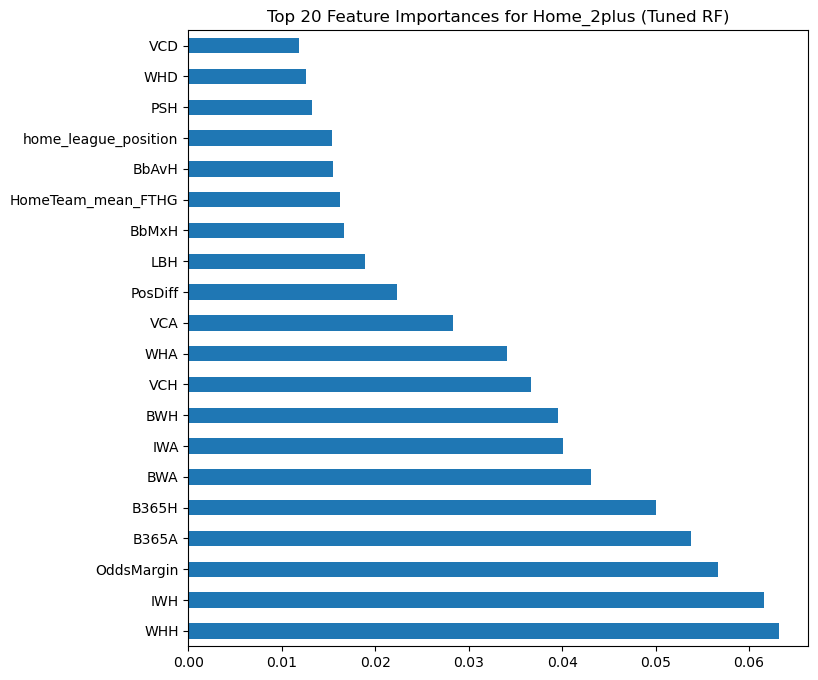

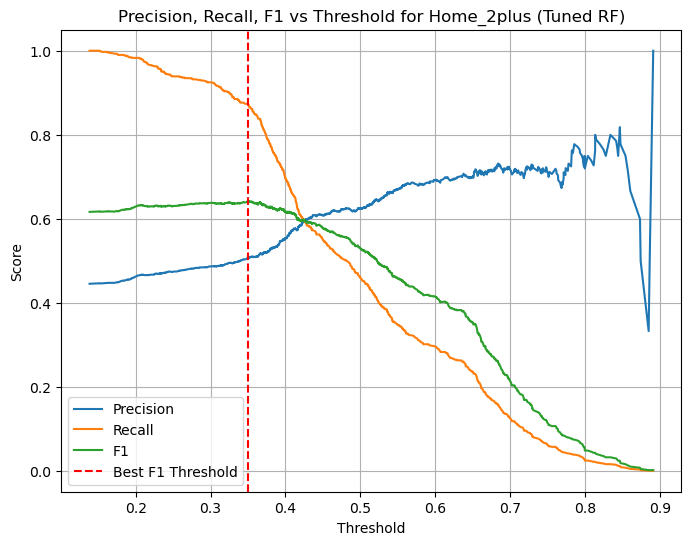

In [27]:
best_rf, best_threshold = train_home2plus_rf(train_df_clean, cols_to_drop, param_grid)

In [31]:
target_col = "Home_2plus"
X_train = train_df_clean.drop(columns=[target_col])
feature_list = X_train.columns.tolist()

model_filename = f"rf_{target_col}_best.pkl"
joblib.dump(best_rf, model_filename)

feature_list_filename = f"rf_{target_col}_feature_list.pkl"
joblib.dump(feature_list, feature_list_filename)

print(f"Saved best RF model for {target_col} to {model_filename}")
print(f"Saved feature list for {target_col} to {feature_list_filename}")

Saved best RF model for Home_2plus to rf_Home_2plus_best.pkl
Saved feature list for Home_2plus to rf_Home_2plus_feature_list.pkl


In [32]:
eval_df_clean.to_csv("../../data/evaluation/secondIterration/eval_df_clean.csv", index=False)